# AI-Powered Customer Support Automation using Classification Models and Generative AI

**Domain:** NLP + Generative AI | **Dataset:** `Tobi-Bueck/customer-support-tickets` (Hugging Face)

This Colab notebook covers the full project end-to-end:

1. Dataset Exploration
2. Preprocessing, Feature Engineering & Label Encoding
3. Baseline ML Models (Logistic Regression, Naive Bayes, SVM) + RNN/LSTM
4-6. Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix) & Hyperparameter Tuning
7. Gemini API integration for automatic polite replies
8-9. Testing & sample outputs
10. Streamlit app (optional, via tunnel)

> **How to run:** `Runtime -> Run all`. For Gemini, add your key in Colab `Secrets` (key icon, left sidebar) as `GEMINI_API_KEY`, or paste it when prompted.

**Skills demonstrated:** Text preprocessing & tokenization, TF-IDF, Logistic Regression / Naive Bayes / SVM, RNN/LSTM (Keras), model evaluation, class-imbalance handling, ML + GenAI integration, prompt engineering, Streamlit deployment.

In [ ]:
# ===== Install dependencies (Colab) =====
!pip -q install datasets google-generativeai textblob >/dev/null 2>&1
print("Dependencies installed. TensorFlow, scikit-learn, pandas, matplotlib, seaborn, nltk come pre-installed in Colab.")

Dependencies installed. TensorFlow, scikit-learn, pandas, matplotlib, seaborn, nltk come pre-installed in Colab.


In [ ]:
# ===== Imports & configuration =====
import re, string, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
STOP_WORDS = set(stopwords.words("english"))

# ---- Project config ----
TEXT_COLUMN   = "body"      # input: ticket text
TARGET_COLUMN = "queue"     # target: department/queue
TOP_N_QUEUES  = 10          # keep N most frequent queues (set None for all 52)
MAX_SAMPLES   = 15000       # subsample for speed (set None for full dataset)
MAX_LEN       = 200
VOCAB_SIZE    = 20000
EMBED_DIM     = 128
LSTM_UNITS    = 64
BATCH_SIZE    = 64
EPOCHS        = 8
RANDOM_STATE  = 42
GEMINI_MODEL  = "gemini-2.5-flash"   # change to "gemini-2.5-pro" if you have access

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Step 1 - Dataset Exploration

In [ ]:
# ===== Load dataset from Hugging Face =====
from datasets import load_dataset

ds = load_dataset("Tobi-Bueck/customer-support-tickets")
split = "train" if "train" in ds else list(ds.keys())[0]
df = pd.DataFrame(ds[split])

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df[[TEXT_COLUMN, TARGET_COLUMN]].head()

README.md:   0%|          | 0.00/7.68k [00:00<?, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv:   0%|          | 0.00/8.33M [00:00<?, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Shape: (61765, 16)
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,body,queue
0,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Technical Support
1,"Dear Customer Support Team,\n\nI am writing to...",Technical Support
2,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges
3,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments
4,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales


Missing values in key columns:
body     2
queue    0
dtype: int64 

Avg word count: 57.4
Total queues: 52

Top queues:
 queue
Technical Support                      14186
Product Support                         8960
Customer Service                        7420
IT Support                              5725
Billing and Payments                    4874
Returns and Exchanges                   2438
Service Outages and Maintenance         1912
Sales and Pre-Sales                     1490
Human Resources                          914
General Inquiry                          668
Pets & Animals/Pet Services              386
News                                     383
IT & Technology/Security Operations      365
Autos & Vehicles/Sales                   364
Health/Medical Services                  362
Name: count, dtype: int64


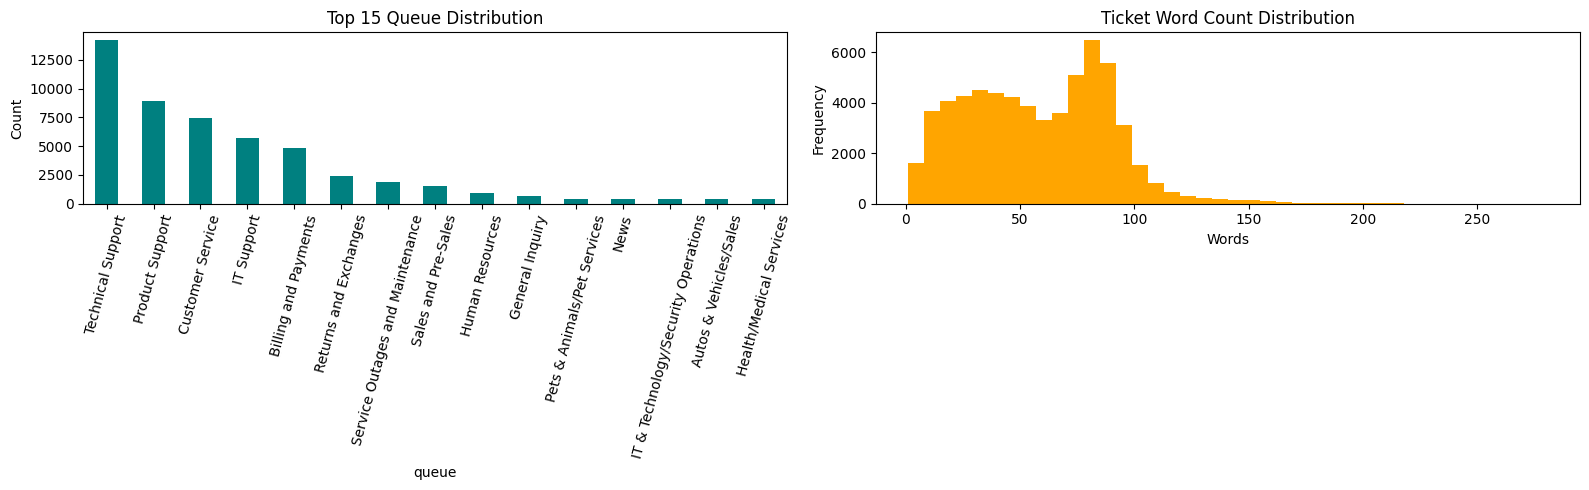

In [ ]:
# ===== Explore: missing values, length, queue distribution =====
print("Missing values in key columns:")
print(df[[TEXT_COLUMN, TARGET_COLUMN]].isnull().sum(), "\n")

df["word_count"] = df[TEXT_COLUMN].astype(str).str.split().str.len()
print(f"Avg word count: {df['word_count'].mean():.1f}")
print(f"Total queues: {df[TARGET_COLUMN].nunique()}\n")

top = df[TARGET_COLUMN].value_counts().head(15)
print("Top queues:\n", top)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
top.plot(kind="bar", ax=ax[0], color="teal")
ax[0].set_title("Top 15 Queue Distribution"); ax[0].set_ylabel("Count")
ax[0].tick_params(axis="x", rotation=75)

df["word_count"].clip(upper=300).plot(kind="hist", bins=40, ax=ax[1], color="orange")
ax[1].set_title("Ticket Word Count Distribution"); ax[1].set_xlabel("Words")
plt.tight_layout(); plt.show()

## Step 2 - Preprocessing, Feature Engineering & Label Encoding

Text cleaning (lowercase, remove URLs/punctuation/digits) -> stopword removal -> engineered features (keywords, sentiment, urgency, length) -> label encoding. We optionally keep the top-N queues to make the multi-class problem more tractable for a demo.

In [ ]:
# ===== Text cleaning & preprocessing =====
URGENCY_KW = ["urgent", "asap", "immediately", "critical", "emergency", "priority"]
BILLING_KW = ["refund", "payment", "billing", "charge", "invoice", "subscription"]
TECH_KW    = ["login", "error", "bug", "crash", "password", "install", "update"]

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text: str) -> str:
    cleaned = clean_text(text)
    tokens = [t for t in nltk.word_tokenize(cleaned)
              if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

# ---- Filter to top-N queues + drop missing ----
data = df.dropna(subset=[TEXT_COLUMN, TARGET_COLUMN]).copy()
if TOP_N_QUEUES:
    keep = data[TARGET_COLUMN].value_counts().head(TOP_N_QUEUES).index
    data = data[data[TARGET_COLUMN].isin(keep)]
if MAX_SAMPLES and len(data) > MAX_SAMPLES:
    data = data.groupby(TARGET_COLUMN, group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(1, MAX_SAMPLES // data[TARGET_COLUMN].nunique())),
                           random_state=RANDOM_STATE))
data = data.reset_index(drop=True)

# ---- Clean text ----
from textblob import TextBlob
data["clean_text"] = data[TEXT_COLUMN].apply(preprocess)
data = data[data["clean_text"].str.strip() != ""].reset_index(drop=True)

# ---- Feature engineering ----
def kw_count(t, kws): return sum(1 for k in kws if k in t)
ct = data["clean_text"]
data["wc"]        = ct.str.split().str.len()
data["urgency"]   = ct.apply(lambda t: kw_count(t, URGENCY_KW))
data["billing"]   = ct.apply(lambda t: kw_count(t, BILLING_KW))
data["tech"]      = ct.apply(lambda t: kw_count(t, TECH_KW))
data["sentiment"] = ct.apply(lambda t: TextBlob(t).sentiment.polarity if t.strip() else 0.0)

print("Records after preprocessing:", len(data))
print("Queues used:", data[TARGET_COLUMN].nunique())
data[["clean_text", "wc", "urgency", "billing", "tech", "sentiment", TARGET_COLUMN]].head()

Records after preprocessing: 13572
Queues used: 10


,clean_text,wc,urgency,billing,tech,sentiment,queue
0,customer support could provide details data se...,36,0,0,0,0.05,Billing and Payments
1,sehr geehrte kundensupport ich bitte um inform...,53,0,0,0,0.00,Billing and Payments
2,possible get details using docker data analyti...,13,0,0,0,0.00,Billing and Payments
3,sehr geehrter kundenservice ich möchte die imp...,84,0,0,0,0.00,Billing and Payments
4,ich möchte eine aktualisierung der rechnungsst...,55,0,0,0,0.00,Billing and Payments


In [ ]:
# ===== Label encoding & train/test split =====
le = LabelEncoder()
data["label"] = le.fit_transform(data[TARGET_COLUMN])
NUM_CLASSES = len(le.classes_)

train_df, test_df = train_test_split(
    data, test_size=0.2, random_state=RANDOM_STATE, stratify=data["label"])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

y_train = train_df["label"].values
y_test  = test_df["label"].values

print("Classes:", list(le.classes_))
print(f"Train: {len(train_df)} | Test: {len(test_df)} | Classes: {NUM_CLASSES}")

Classes: ['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']
Train: 10857 | Test: 2715 | Classes: 10


## Step 3 - Baseline Models (Logistic Regression, Naive Bayes, SVM)

TF-IDF features (1-2 grams) feed three classic models that serve as benchmarks for the LSTM.

In [ ]:
# ===== Train & evaluate baseline models =====
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
Xtr = tfidf.fit_transform(train_df["clean_text"])
Xte = tfidf.transform(test_df["clean_text"])

def evaluate(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

baselines = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Naive Bayes":         MultinomialNB(),
    "SVM (LinearSVC)":     LinearSVC(class_weight="balanced"),
}

results, fitted = [], {}
for name, model in baselines.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    results.append(evaluate(name, y_test, preds))
    fitted[name] = model
    print(f"{name:22s} | acc={results[-1]['accuracy']:.3f} f1={results[-1]['f1']:.3f}")

results_df = pd.DataFrame(results).set_index("model").round(3)
results_df

Logistic Regression    | acc=0.435 f1=0.429
Naive Bayes            | acc=0.360 f1=0.342
SVM (LinearSVC)        | acc=0.488 f1=0.481


,accuracy,precision,recall,f1
model,,,,
Logistic Regression,0.435,0.429,0.435,0.429
Naive Bayes,0.360,0.435,0.360,0.342
SVM (LinearSVC),0.488,0.477,0.488,0.481


Best baseline: SVM (LinearSVC) 

                                 precision    recall  f1-score   support

           Billing and Payments       0.69      0.69      0.69       300
               Customer Service       0.33      0.32      0.32       300
                General Inquiry       0.50      0.60      0.55       134
                Human Resources       0.61      0.68      0.64       183
                     IT Support       0.38      0.37      0.37       300
                Product Support       0.29      0.22      0.25       300
          Returns and Exchanges       0.46      0.48      0.47       300
            Sales and Pre-Sales       0.57      0.66      0.61       298
Service Outages and Maintenance       0.68      0.71      0.70       300
              Technical Support       0.32      0.29      0.30       300

                       accuracy                           0.49      2715
                      macro avg       0.48      0.50      0.49      2715
                

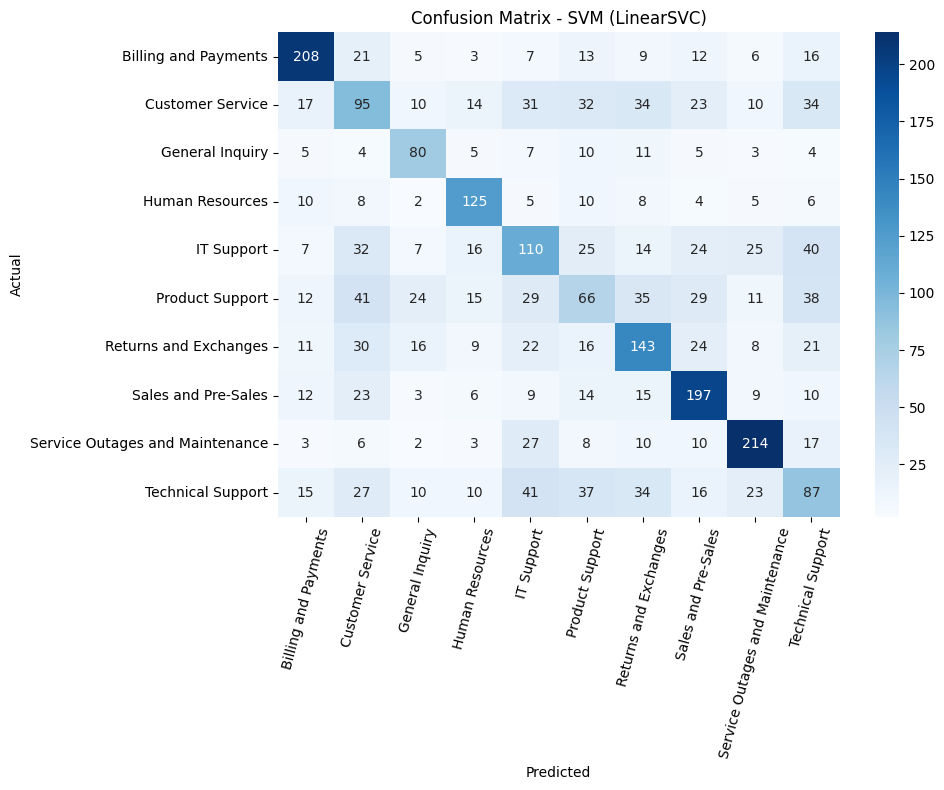

In [ ]:
# ===== Confusion matrix for best baseline =====
best_baseline_name = results_df["f1"].idxmax()
best_baseline = fitted[best_baseline_name]
preds = best_baseline.predict(Xte)
print("Best baseline:", best_baseline_name, "\n")
print(classification_report(y_test, preds, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix - {best_baseline_name}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=75); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## Step 3b - Many-to-One RNN using LSTM

Tokens -> Embedding -> LSTM (final hidden state) -> Dense + Softmax to predict the queue.

In [ ]:
# ===== Tokenize & pad sequences for LSTM =====
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["clean_text"])

def to_padded(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

Xtr_seq = to_padded(train_df["clean_text"])
Xte_seq = to_padded(test_df["clean_text"])

# validation split
Xtr_seq, Xval_seq, ytr_l, yval_l = train_test_split(
    Xtr_seq, y_train, test_size=0.1, random_state=RANDOM_STATE, stratify=y_train)

ytr_cat  = to_categorical(ytr_l,  NUM_CLASSES)
yval_cat = to_categorical(yval_l, NUM_CLASSES)

# class weights for imbalance
classes, counts = np.unique(ytr_l, return_counts=True)
total = len(ytr_l)
class_weights = {int(c): total / (len(classes) * n) for c, n in zip(classes, counts)}

vocab = min(VOCAB_SIZE, int(Xtr_seq.max()) + 1)
print("Padded train:", Xtr_seq.shape, "| vocab:", vocab)

Padded train: (9771, 200) | vocab: 15509


In [ ]:
# ===== Build & train the LSTM =====
def build_lstm(vocab, num_classes, embed_dim=EMBED_DIM, units=LSTM_UNITS, dropout=0.3):
    model = Sequential([
        Embedding(input_dim=vocab, output_dim=embed_dim, input_length=MAX_LEN),
        LSTM(units),
        Dropout(dropout),
        Dense(64, activation="relu"),
        Dropout(dropout),
        Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

lstm = build_lstm(vocab, NUM_CLASSES)
lstm.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]

history = lstm.fit(
    Xtr_seq, ytr_cat,
    validation_data=(Xval_seq, yval_cat),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights, callbacks=callbacks, verbose=1,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
153/153 ━━━━━━━━━━━━━━━━━━━━ 45s 274ms/step - accuracy: 0.0918 - loss: 2.3048 - val_accuracy: 0.1105 - val_loss: 2.3026 - learning_rate: 0.0010
Epoch 2/8
153/153 ━━━━━━━━━━━━━━━━━━━━ 40s 259ms/step - accuracy: 0.0975 - loss: 2.3037 - val_accuracy: 0.1105 - val_loss: 2.3009 - learning_rate: 0.0010
Epoch 3/8
153/153 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.0971 - loss: 2.3037 - val_accuracy: 0.0497 - val_loss: 2.3030 - learning_rate: 0.0010
Epoch 4/8
153/153 ━━━━━━━━━━━━━━━━━━━━ 40s 261ms/step - accuracy: 0.0903 - loss: 2.3034 - val_accuracy: 0.1105 - val_loss: 2.3028 - learning_rate: 0.0010
Epoch 5/8
153/153 ━━━━━━━━━━━━━━━━━━━━ 40s 261ms/step - accuracy: 0.0778 - loss: 2.3029 - val_accuracy: 0.1105 - val_loss: 2.3034 - learning_rate: 5.0000e-04


## Steps 4-6 - Evaluation & Hyperparameter Tuning

LSTM  acc=0.110  f1=0.022

                                 precision    recall  f1-score   support

           Billing and Payments       0.00      0.00      0.00       300
               Customer Service       0.00      0.00      0.00       300
                General Inquiry       0.00      0.00      0.00       134
                Human Resources       0.00      0.00      0.00       183
                     IT Support       0.11      1.00      0.20       300
                Product Support       0.00      0.00      0.00       300
          Returns and Exchanges       0.00      0.00      0.00       300
            Sales and Pre-Sales       0.00      0.00      0.00       298
Service Outages and Maintenance       0.00      0.00      0.00       300
              Technical Support       0.00      0.00      0.00       300

                       accuracy                           0.11      2715
                      macro avg       0.01      0.10      0.02      2715
                   wei

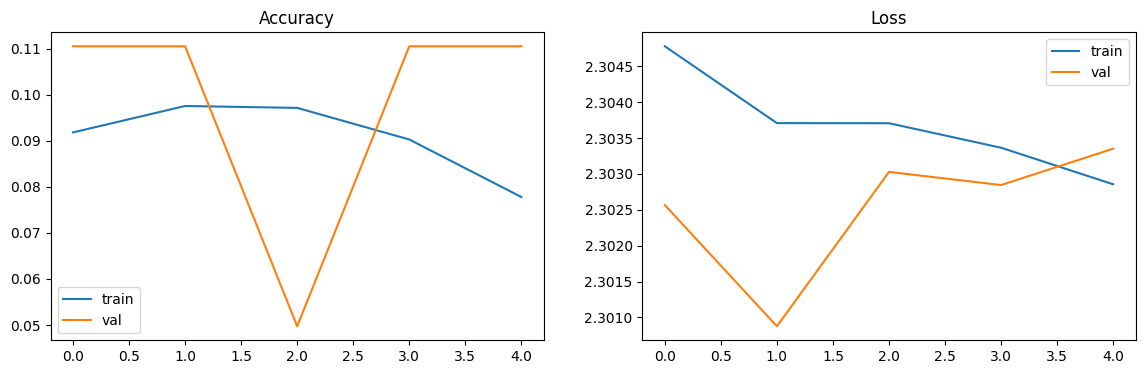

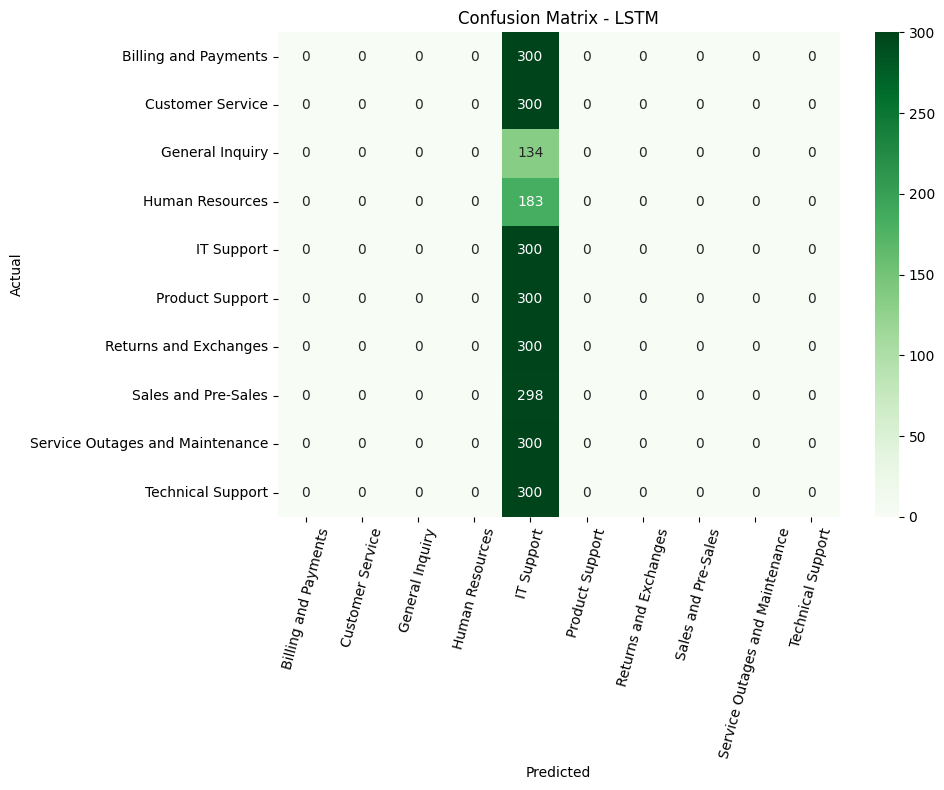

In [ ]:
# ===== Evaluate the LSTM on the test set =====
lstm_probs = lstm.predict(Xte_seq, verbose=0)
lstm_preds = np.argmax(lstm_probs, axis=1)

lstm_metrics = evaluate("LSTM", y_test, lstm_preds)
print(f"LSTM  acc={lstm_metrics['accuracy']:.3f}  f1={lstm_metrics['f1']:.3f}\n")
print(classification_report(y_test, lstm_preds, target_names=le.classes_, zero_division=0))

# Training curves
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(history.history["accuracy"], label="train")
ax[0].plot(history.history["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].legend()
ax[1].plot(history.history["loss"], label="train")
ax[1].plot(history.history["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, lstm_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - LSTM"); plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=75); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

=== All models ===
                     accuracy  precision  recall     f1
model                                                  
Logistic Regression     0.435      0.429   0.435  0.429
Naive Bayes             0.360      0.435   0.360  0.342
SVM (LinearSVC)         0.488      0.477   0.488  0.481
LSTM                    0.110      0.012   0.110  0.022


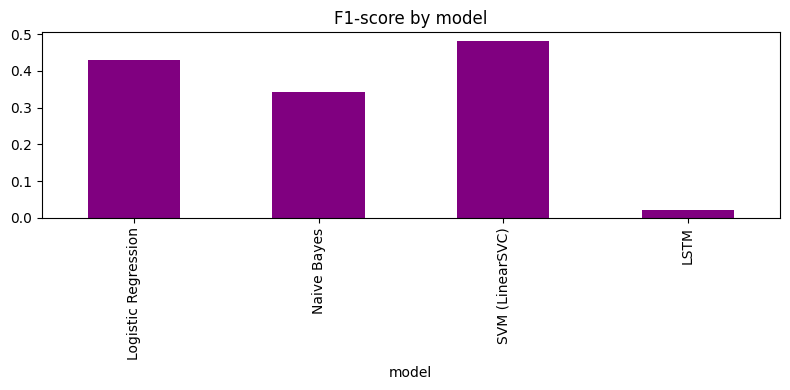


=== LSTM hyperparameter tuning (validation F1) ===
units=32, embed=64 -> val F1=0.022
units=32, embed=128 -> val F1=0.022
units=64, embed=64 -> val F1=0.022
units=64, embed=128 -> val F1=0.022

Best config: {'units': 32, 'embed': 64} | val F1: 0.022


In [ ]:
# ===== Model comparison + simple LSTM hyperparameter tuning =====
all_results = pd.DataFrame(results + [lstm_metrics]).set_index("model").round(3)
print("=== All models ===")
print(all_results)

all_results["f1"].plot(kind="bar", color="purple", figsize=(8, 4),
                       title="F1-score by model"); plt.tight_layout(); plt.show()

# ---- Small grid search over LSTM units / embedding dim ----
print("\n=== LSTM hyperparameter tuning (validation F1) ===")
best_cfg, best_val_f1 = None, -1
for units in [32, 64]:
    for emb in [64, 128]:
        m = build_lstm(vocab, NUM_CLASSES, embed_dim=emb, units=units)
        m.fit(Xtr_seq, ytr_cat, validation_data=(Xval_seq, yval_cat),
              epochs=3, batch_size=BATCH_SIZE, class_weight=class_weights, verbose=0)
        vpred = np.argmax(m.predict(Xval_seq, verbose=0), axis=1)
        vf1 = f1_score(yval_l, vpred, average="weighted", zero_division=0)
        print(f"units={units}, embed={emb} -> val F1={vf1:.3f}")
        if vf1 > best_val_f1:
            best_val_f1, best_cfg = vf1, {"units": units, "embed": emb}

print("\nBest config:", best_cfg, "| val F1:", round(best_val_f1, 3))

## Step 7 - Gemini API Integration (Automatic Replies)

After predicting the queue, send `ticket text + predicted queue` to Gemini to draft a polite acknowledgment.

**Add your key:** click the key icon (Secrets) in the left sidebar -> add `GEMINI_API_KEY`. Get a free key at https://aistudio.google.com/app/apikey

In [ ]:
import os
import google.generativeai as genai

GEMINI_MODEL = "gemini-2.5-flash"
KEY_FILE = "/content/Gemini_API_Key.txt"

def _load_key_from_file(path):
    try:
        with open(path) as f:
            content = f.read().strip()
    except Exception:
        return None
    # supports "GEMINI_API_KEY=xxx" or just "xxx"
    if "=" in content:
        content = content.split("=", 1)[1]
    return content.strip().strip('"').strip("'") or None

GEMINI_API_KEY = None
# 1) Colab Secrets (key icon in sidebar)
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    pass
# 2) Environment variable
if not GEMINI_API_KEY:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
# 3) From the text file you created
if not GEMINI_API_KEY:
    GEMINI_API_KEY = _load_key_from_file(KEY_FILE)
# 4) Manual entry
if not GEMINI_API_KEY:
    from getpass import getpass
    GEMINI_API_KEY = getpass("Enter your GEMINI_API_KEY (or press Enter to skip): ").strip() or None

if GEMINI_API_KEY:
    genai.configure(api_key=GEMINI_API_KEY)
    print("Gemini configured with model:", GEMINI_MODEL)
    print("Key loaded -> prefix:", GEMINI_API_KEY[:4], "| length:", len(GEMINI_API_KEY))
else:
    print("No API key provided - a polite template fallback will be used.")

Gemini configured with model: gemini-2.5-flash
Key loaded -> prefix: AQ.A | length: 53


## Steps 8-9 - Unified Pipeline & Sample Outputs

One function: ticket text -> predicted queue -> Gemini reply. Choose `"lstm"` or any baseline model.

In [ ]:
# ===== End-to-end prediction function =====
def classify_and_reply(ticket_text, model_type="lstm", make_reply=True):
    clean = preprocess(ticket_text)
    if model_type == "lstm":
        seq = to_padded([clean])
        probs = lstm.predict(seq, verbose=0)[0]
        idx = int(np.argmax(probs))
        confidence = float(np.max(probs))
    else:
        model = fitted.get(model_type, best_baseline)
        vec = tfidf.transform([clean])
        idx = int(model.predict(vec)[0])
        confidence = None
    queue = le.inverse_transform([idx])[0]
    out = {"predicted_queue": queue, "confidence": confidence, "model": model_type}
    if make_reply:
        out["reply"] = generate_reply(ticket_text, queue)
    return out

samples = [
    "I was charged twice for my subscription this month and need an urgent refund.",
    "The app keeps crashing on login after the latest update, please help asap.",
    "How do I update my billing address and company name on my account?",
]
for s in samples:
    r = classify_and_reply(s, model_type="lstm")
    print("Ticket :", s)
    print("Queue  :", r["predicted_queue"],
          f"(conf={r['confidence']:.2f})" if r["confidence"] else "")
    print("Reply  :", r["reply"])
    print("-" * 90)

Ticket : I was charged twice for my subscription this month and need an urgent refund.
Queue  : IT Support (conf=0.10)
Reply  : Thank you for contacting customer support. We understand you're experiencing an issue with duplicate charges for your subscription and are seeking a refund. Your ticket has been successfully routed to our IT Support team for review. Please be assured that they are looking into this matter and will provide an update as soon as possible.
------------------------------------------------------------------------------------------
Ticket : The app keeps crashing on login after the latest update, please help asap.
Queue  : IT Support (conf=0.10)
Reply  : Subject: Re: Your Support Ticket - App Crashing on Login

Thank you for contacting our support team. We understand you're experiencing an issue with the app crashing on login after the latest update, and we apologize for any inconvenience this may be causing. Your ticket has been successfully routed to our IT Support

In [ ]:
# ===== Save trained artifacts (download to your machine) =====
import joblib
lstm.save("lstm_ticket_classifier.keras")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(best_baseline, "baseline_best.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(tokenizer, "tokenizer.pkl")
print("Saved: lstm_ticket_classifier.keras, tfidf_vectorizer.pkl, baseline_best.pkl, label_encoder.pkl, tokenizer.pkl")

# Uncomment to download:
# from google.colab import files
# for f in ["lstm_ticket_classifier.keras","tfidf_vectorizer.pkl","baseline_best.pkl","label_encoder.pkl","tokenizer.pkl"]:
#     files.download(f)

Saved: lstm_ticket_classifier.keras, tfidf_vectorizer.pkl, baseline_best.pkl, label_encoder.pkl, tokenizer.pkl


## Step 10 - Streamlit App (optional, runs from Colab)

This writes `app.py` and serves it through a public tunnel. Run the two cells below, then open the printed URL and enter the tunnel password (the cell prints your Colab's external IP to paste as the password).

In [ ]:
# ===== Write the Streamlit app =====
app_code = '''
import re, string, os
import numpy as np
import joblib
import streamlit as st
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import google.generativeai as genai

nltk.download("stopwords", quiet=True); nltk.download("punkt", quiet=True); nltk.download("punkt_tab", quiet=True)
STOP = set(stopwords.words("english"))
MAX_LEN = 200
GEMINI_MODEL = "gemini-2.5-flash"

@st.cache_resource
def load_all():
    return (load_model("lstm_ticket_classifier.keras"),
            joblib.load("tokenizer.pkl"),
            joblib.load("tfidf_vectorizer.pkl"),
            joblib.load("baseline_best.pkl"),
            joblib.load("label_encoder.pkl"))

lstm, tokenizer, tfidf, baseline, le = load_all()

def preprocess(t):
    t = str(t).lower(); t = re.sub(r"http\\S+|www\\S+", " ", t)
    t = t.translate(str.maketrans("", "", string.punctuation))
    t = re.sub(r"\\d+", " ", t); t = re.sub(r"\\s+", " ", t).strip()
    return " ".join([w for w in nltk.word_tokenize(t) if w not in STOP and len(w) > 1])

key = os.environ.get("GEMINI_API_KEY")
if key: genai.configure(api_key=key)

def reply(text, queue):
    if not key:
        return (f"Thank you for contacting support. Your request is routed to our {queue} "
                f"team and is being reviewed. We will update you shortly.")
    p = (f"You are a support assistant. Ticket: {text}. It is routed to {queue}. "
         f"Write a polite 3-5 sentence acknowledgment, no invented details.")
    try:
        return genai.GenerativeModel(GEMINI_MODEL).generate_content(p).text.strip()
    except Exception as e:
        return f"Thank you for contacting support. Routed to {queue}. [Gemini: {e}]"

st.set_page_config(page_title="Support Ticket Automation", page_icon="🎫")
st.title("AI-Powered Customer Support Automation")
mtype = st.sidebar.selectbox("Model", ["lstm", "baseline"])
txt = st.text_area("Enter a support ticket", height=180)

if st.button("Classify & Generate Reply"):
    if not txt.strip():
        st.warning("Please enter a ticket.")
    else:
        clean = preprocess(txt)
        if mtype == "lstm":
            probs = lstm.predict(pad_sequences(tokenizer.texts_to_sequences([clean]),
                                 maxlen=MAX_LEN, padding="post", truncating="post"), verbose=0)[0]
            idx, conf = int(np.argmax(probs)), float(np.max(probs))
        else:
            idx, conf = int(baseline.predict(tfidf.transform([clean]))[0]), None
        queue = le.inverse_transform([idx])[0]
        st.success(f"Predicted Queue: {queue}")
        if conf: st.metric("Confidence", f"{conf:.1%}")
        st.markdown("#### Generated Reply")
        st.info(reply(txt, queue))
'''
with open("app.py", "w") as f:
    f.write(app_code)
print("app.py written.")

# pass the Gemini key to the app process if available
if GEMINI_API_KEY:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

app.py written.


In [ ]:
# ===== Launch Streamlit via tunnel =====
# Your tunnel password = the IP printed below. Open the printed *.loca.lt URL and paste it.
!pip -q install streamlit >/dev/null 2>&1
!wget -q -O - https://loca.lt/mytunnelpassword ; print()
!streamlit run app.py &>/content/st.log &
!sleep 5 && npx --yes localtunnel --port 8501

/bin/bash: -c: line 2: syntax error: unexpected end of file
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://bright-socks-turn.loca.lt
